### Фокин Никита 5130901/30201

## Упражнения к главе 9

### Упражнение 9.2

В ходе выполнения данного урпажнения был создан треугольный сигнал с частото1 100 Гц:

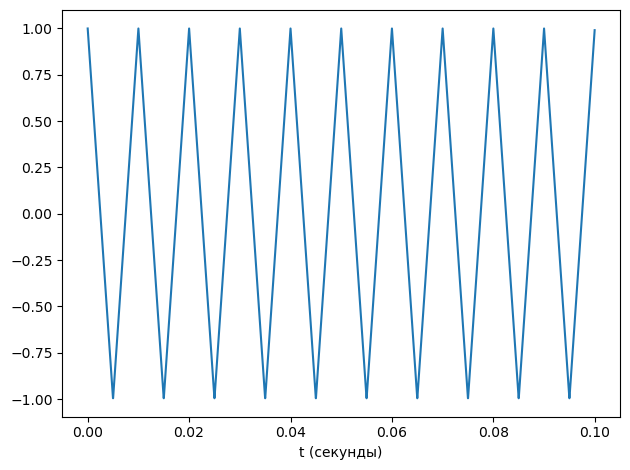

In [53]:
from thinkdsp import TriangleSignal, decorate

wave = TriangleSignal(freq=100).make_wave(duration=0.1, framerate=44100)
wave.plot()
decorate(xlabel='t (секунды)')

Далее к нему был применен метод diff, вследсвие чего был получен прямоугольный сигнал

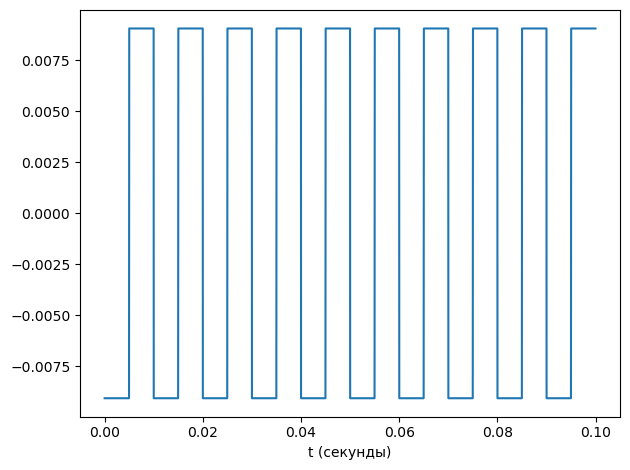

In [54]:
waveDiff = wave.diff()
waveDiff.plot()
decorate(xlabel='t (секунды)')

И теперь метод получения спекральной производной differentiate, по графику которого видно, что вокруг разрывов присутствует "звон":

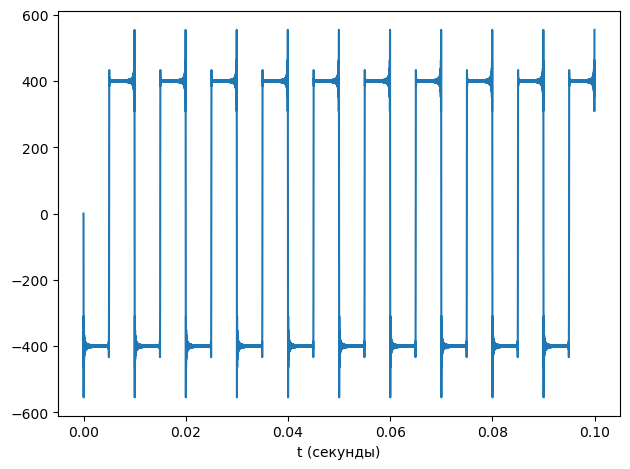

In [55]:
waveDifferentiate = wave.make_spectrum().differentiate().make_wave()
waveDifferentiate.plot()
decorate(xlabel='t (секунды)')

### Упражнение 9.3

В данном упржнении предлагается создать прямоугольную волну:

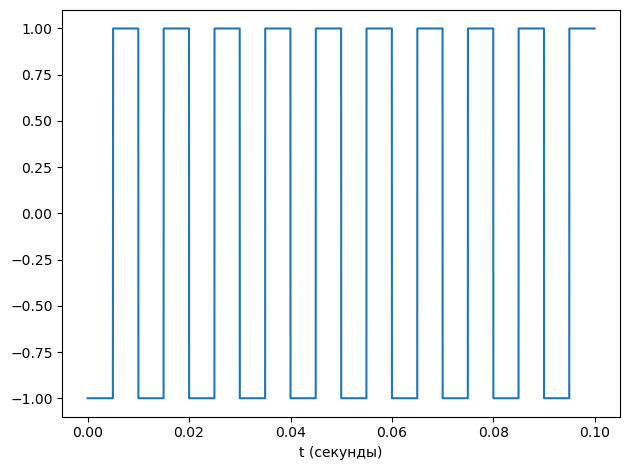

In [57]:
from thinkdsp import SquareSignal

wave = SquareSignal(freq=100).make_wave(duration=0.1, framerate=44100)
wave.plot()
decorate(xlabel='t (секунды)')

Применим к ней метод, возвращающий кумулятивную сумму волны, и получим треугольную:

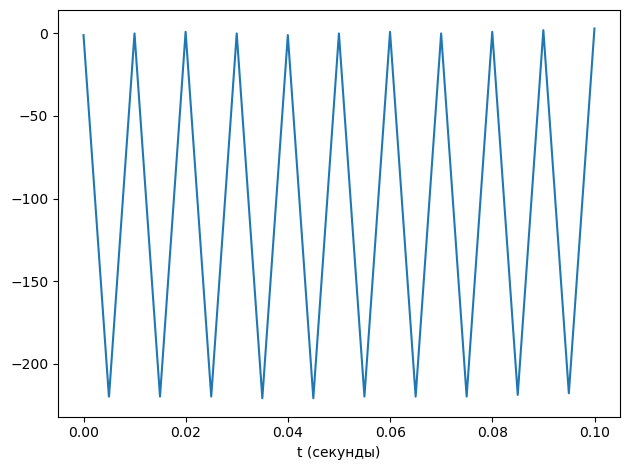

In [60]:
waveCumSum = wave.cumsum()
waveCumSum.plot()
decorate(xlabel='t (секунды)')

Теперь проинтегрируем волну и получим ту же самую картину, но с гораздо меньшей амплитудой:

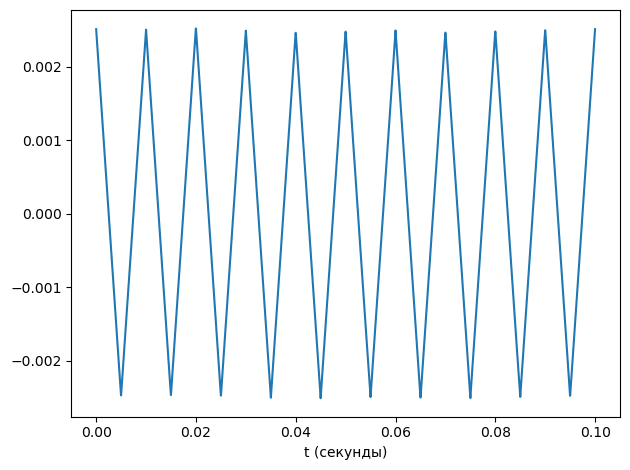

In [61]:
spectrum = wave.make_spectrum().integrate()
spectrum.hs[0] = 0
waveIntegral = spectrum.make_wave()
waveIntegral.plot()
decorate(xlabel='t (секунды)')

Сравним эти волны, применив к ним методы normalize и unbias:

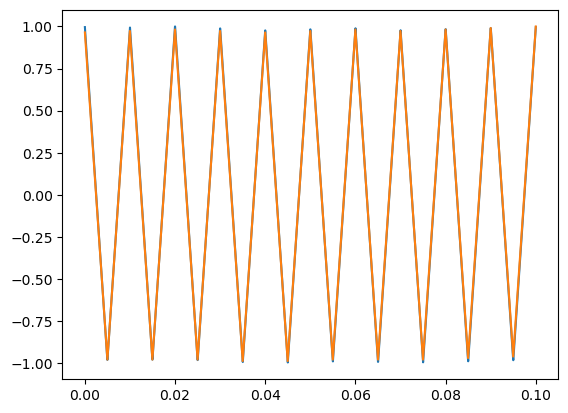

In [65]:
waveIntegral.unbias()
waveIntegral.normalize()
waveCumSum.normalize()
waveIntegral.plot()
waveCumSum.plot()

### Упражнение 9.4

Создадим пилообразный сигнал:

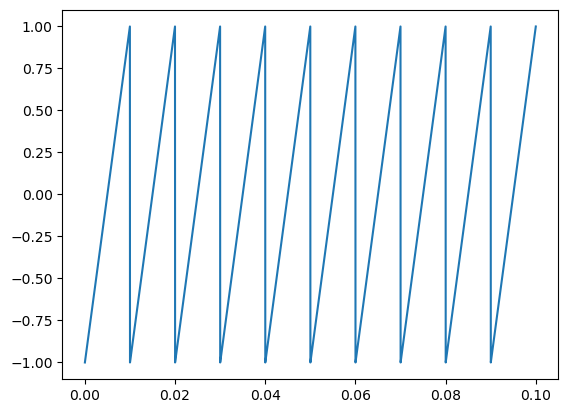

In [66]:
from thinkdsp import SawtoothSignal

waveST = SawtoothSignal(freq=100).make_wave(duration=0.1, framerate=44100)
waveST.plot()

Теперь дважды применим к ней метод интегрирования:

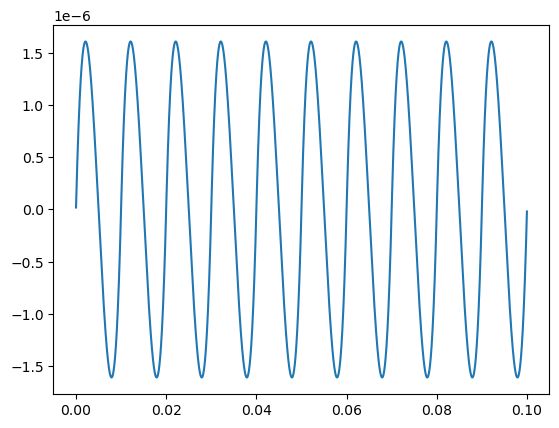

In [67]:
spectrum = waveST.make_spectrum().integrate().integrate()
spectrum.hs[0] = 0
waveInt2 = spectrum.make_wave()
waveInt2.plot()

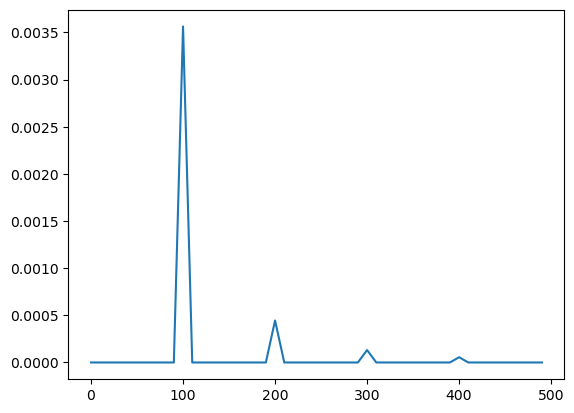

In [68]:
waveInt2.make_spectrum().plot(high=500)

Таким образом, сигнал становится похожим на синусоиду

### Упражнение 9.5

Создадим CubicSignal:

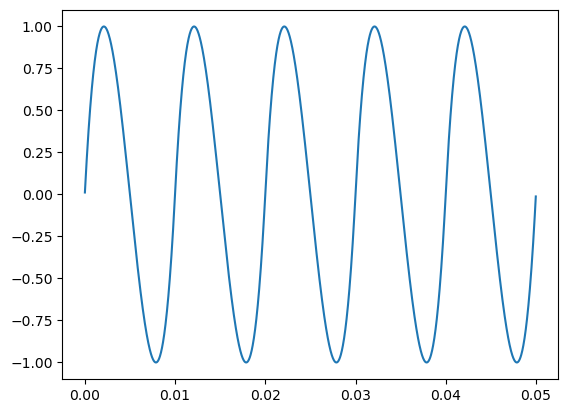

In [80]:
from thinkdsp import CubicSignal

wave = CubicSignal(freq=100).make_wave(duration=0.05, framerate=44100)
wave.plot()

Продифференцируем ее и получим параболу в качестве первой производной и пилообразный сигнал в качестве второй:

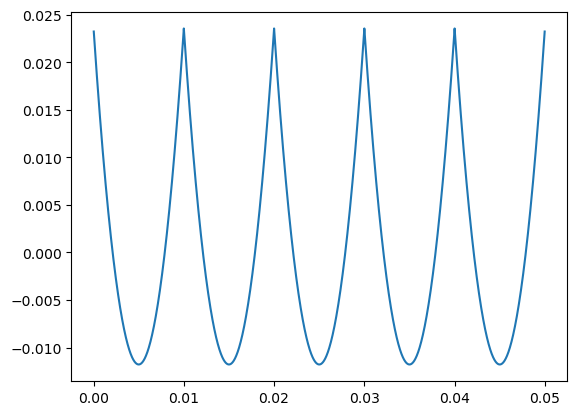

In [81]:
waveDiff1 = wave.diff()
waveDiff1.plot()

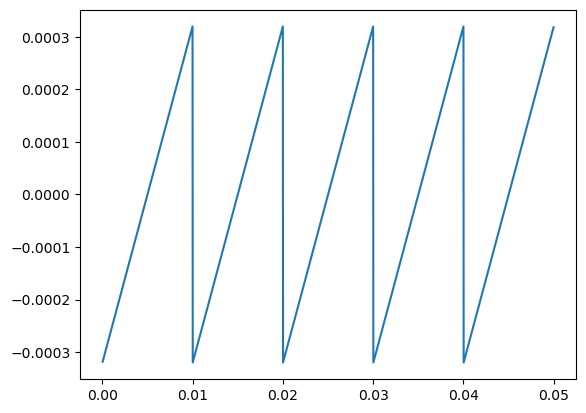

In [82]:
waveDiff2 = waveDiff1.diff()
waveDiff2.plot()

Возьмем дважды спектральную производну с помощью differentiate и получим пиллобразный сигнал со "звоном":

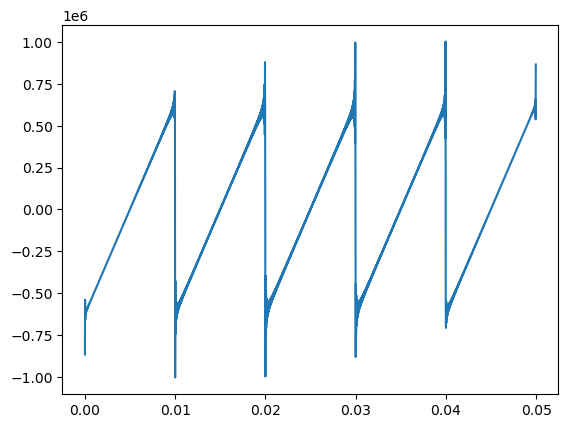

In [83]:
spectrum = wave.make_spectrum().differentiate().differentiate()
waveDifferentiate2 = spectrum.make_wave()
waveDifferentiate2.plot()

Найдем фильтры для второй разнице и второй производной:

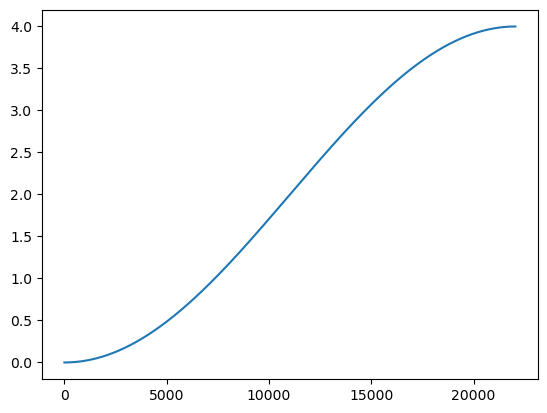

In [87]:
import numpy as np
from thinkdsp import zero_pad
from thinkdsp import Wave

window = np.array([-1.0, 2.0, -1.0])
padded = zero_pad(window, len(wave))
diff_wave = Wave(padded, framerate=wave.framerate)
diff_filter = diff_wave.make_spectrum()
diff_filter.plot()

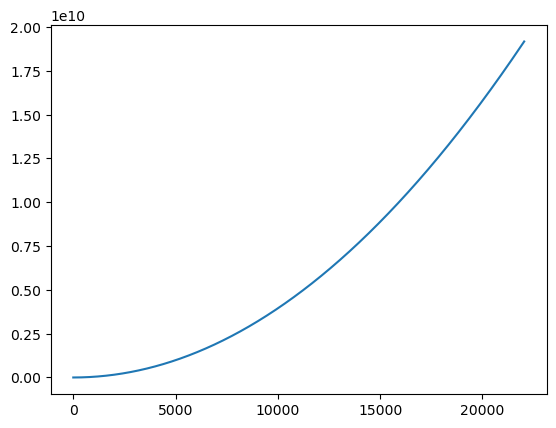

In [88]:
deriv_filter = wave.make_spectrum()
deriv_filter.hs = (np.pi * 2 * 1j * deriv_filter.fs)**2
deriv_filter.plot(label='2nd deriv')

Таким образом, оба фильтра являются фильтрами верхних частот, усиливающими высокочастотные составляющие.